In [ ]:
import sys, os
sys.path.insert(0, r"C:\Users\Utente\Desktop\progetto vscode\src")

In [2]:

import numpy as np
import networkx as nx
import ot
import matplotlib.pyplot as plt
import seaborn as sns
import random
# from EDRep import NodeEmbedding  
from functions import *
import pandas as pd
import glob
import itertools

from EDRep_main.EDRep import NodeEmbedding

In [3]:
def create_ABIDE_graph(file_name):
    df = pd.read_csv(file_name, sep='\t')

    # columns became numbers not strings
    df.columns = [int(s[1:]) for s in df.columns]
    
    corr_matrix = df.corr().to_numpy().copy()
        
    soglia = 0.5
    adj_matrix = np.where(np.abs(corr_matrix) > soglia, corr_matrix, 0)

    return adj_matrix

In [16]:
def delete_nan(g):
    for line in g:
        for i in range(len(line)):
            if line[i]!= line[i]:
                line[i]=0
            elif line[i]<0:
                line[i]=0
    return g

def node_embedding(g_a, partition_A, dim_embedding,seed=42):
    # save the seed state
    rdn_state = np.random.get_state()
    random.seed(seed)
    np.random.seed(seed)
    embedding_a = NodeEmbedding(g_a, dim=dim_embedding, k=1, verbose=False)
    X_total = embedding_a.X
    X_list = [X_total[list(nodes), :] for nodes in partition_A]
    np.random.set_state(rdn_state)
    return X_list


files_folder = r"C:\Users\Utente\Desktop\progetto vscode\data\abide_data\ABIDE_pcp\cpac\nofilt_noglobal"
names_files = os.listdir(files_folder)

def file_found(file_id_dataframe):
    file_id_str = str(file_id_dataframe)
    # see if this name is in the ffolder of the files
    return any(file_id_str in name for name in names_files)

def f_norm_opt(embx,emby):
    x=np.array([e[0] for e in embx])
    y=np.array([e[0] for e in emby])
    norm00=np.linalg.norm(x.T@x)
    norm11=np.linalg.norm(y.T@y)
    norm01=np.linalg.norm(x.T@y)
    finale_norm=np.sqrt(norm00**2+norm11**2-2*norm01**2)/np.sqrt(2)
    return finale_norm

partition=[[i] for i in range(111)]

folder = r"C:\Users\Utente\Desktop\progetto vscode\data\abide_data\ABIDE_pcp\cpac\nofilt_noglobal"
path_files = glob.glob(os.path.join(folder, "*.1D"))

all_graphs=[]
for file in path_files:
    g=create_ABIDE_graph(file)
    all_graphs.append(g)

all_graphs_wo_nan=[]
for g in all_graphs:
    all_graphs_wo_nan.append(delete_nan(g))

In [18]:
df_phenotipic = pd.read_csv(r"C:\Users\Utente\Desktop\progetto vscode\data\abide_data\ABIDE_pcp\Phenotypic_V1_0b_preprocessed1.csv")

df_def = df_phenotipic[df_phenotipic['FILE_ID'].apply(file_found)]

dx_val = df_def['DX_GROUP'].tolist()
emb_list_control=[]
emb_list_autistic=[]

for g, dx in zip(all_graphs_wo_nan, dx_val):
    if dx == 1:
        # emb_1=node_embedding(g,partition,16)
        emb_1 = np.array(node_embedding(g,partition,32))[:,0,:]
        emb_list_control.append(emb_1)
    elif dx == 2:
        emb_2 = np.array(node_embedding(g,partition,32))[:,0,:]
        emb_list_autistic.append(emb_2)


print(len(emb_list_control))
print(len(emb_list_autistic))


403
468


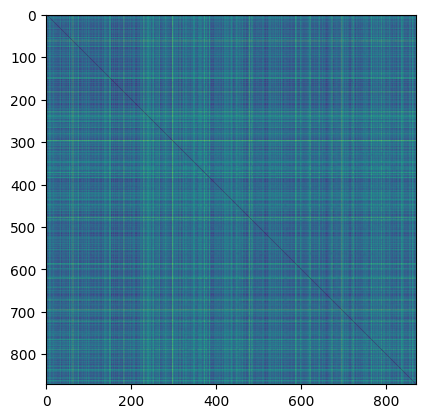

In [19]:


X = np.concatenate([emb_list_control, emb_list_autistic])

n, _, _ = X.shape
D = np.zeros((n,n))

for i in range(n):
    for j in range(n):
        D[i,j] = f_norm_opt(X[i], X[j])
plt.imshow(D)